In [29]:
# ============================================================
# IMPORTACIÓ DE LLIBRERIES
# ============================================================

import pandas as pd
import numpy as np

from scipy.stats import (
    ttest_rel,
    wilcoxon,
    ttest_ind,
    mannwhitneyu,
    shapiro,
    pearsonr,
    spearmanr
)

import statsmodels.api as sm
import statsmodels.formula.api as smf

In [30]:
# ============================================================
# CÀRREGA DE DADES
# ============================================================

from pathlib import Path

# Ruta base
FITXER = Path("Dades/Recollida.xlsx")

# ---------- Intervencions ----------
df_i1 = pd.read_excel(
    FITXER,
    sheet_name="I1",
    header=1
)

df_resultats = pd.read_excel(
    FITXER,
    sheet_name="I2 - Resultats"
)

# ---------- Informació alumnat ----------
df_alumnes = pd.read_excel(
    FITXER,
    sheet_name="Alumnes"
)

# ---------- Comparació I1 vs I2 ----------
df_comparacio = pd.read_excel(
    FITXER,
    sheet_name="Alumne - Comparació I1 vs I2"
)

# ---------- Resultats examen ----------
df_examen = pd.read_excel(
    FITXER,
    sheet_name="Alumne - Resultats Examen"
)

In [31]:
# ============================================================
# PREPARACIÓ I NETEJA DE DADES
# ============================================================

# ------------------------------------------------------------
# UNIFICACIÓ D'IDENTIFICADORS
# ------------------------------------------------------------

df_comparacio = df_comparacio.rename(
    columns={"Codi": "Identificador"}
)

df_examen = df_examen.rename(
    columns={"Codi": "Identificador"}
)

# ------------------------------------------------------------
# FUNCIÓ AUXILIAR:
# CONVERSIÓ DE COMA DECIMAL A FLOAT
# ------------------------------------------------------------

def convertir_decimal(df, columnes):
    """
    Converteix columnes amb coma decimal a format numèric.
    """

    for col in columnes:

        df[col] = (
            df[col]
            .astype(str)
            .str.replace(",", ".", regex=False)
        )

        df[col] = pd.to_numeric(
            df[col],
            errors="coerce"
        )

    return df


# ------------------------------------------------------------
# CONVERSIÓ DE VARIABLES NUMÈRIQUES
# ------------------------------------------------------------

columnes_examen = [
    "Nota_4",
    "Nota_Examen",
    "Nota_Mitjana_Curs",
    "Diferencia_Nota"
]

df_examen = convertir_decimal(
    df_examen,
    columnes_examen
)

df_alumnes = convertir_decimal(
    df_alumnes,
    ["Nota Mitjana Curs"]
)

In [32]:
# ============================================================
# PREPARACIÓ DELS RESULTATS DE LA INTERVENCIÓ
# ============================================================

# ------------------------------------------------------------
# CONFIGURACIÓ
# ------------------------------------------------------------

EXERCICIS = [
    "Exercici 1",
    "Exercici 2",
    "Exercici 3",
    "Exercici 4"
]

COLUMNES_NUMERIQUES = (
    EXERCICIS
    + [
        "Rigor",
        "Identificacio Problemes",
        "Nota_4",
        "Nota_Exercicis"
    ]
)

# ------------------------------------------------------------
# CONVERSIÓ A FORMAT NUMÈRIC
# ------------------------------------------------------------

df_resultats[COLUMNES_NUMERIQUES] = (
    df_resultats[COLUMNES_NUMERIQUES]
    .apply(pd.to_numeric, errors="coerce")
)

# ------------------------------------------------------------
# TAXA DE COMPLECIÓ
# ------------------------------------------------------------

df_resultats["Exercicis_No_Respostos"] = (
    df_resultats[EXERCICIS]
    .eq(-1)
    .sum(axis=1)
)

df_resultats["Exercicis_Contestats"] = (
    df_resultats[EXERCICIS]
    .ne(-1)
    .sum(axis=1)
)

df_resultats["Taxa_Complecio"] = (
    df_resultats["Exercicis_Contestats"]
    / len(EXERCICIS)
) * 100

# ------------------------------------------------------------
# PUNTUACIÓ ACADÈMICA
# ------------------------------------------------------------

In [33]:
# ============================================================
# PREPARACIÓ DEL QÜESTIONARI LIKERT
# ============================================================

ITEMS_LIKERT = [str(i) for i in range(1, 12)]

DIMENSIONS_LIKERT = {
    "comprensio_autoeficacia": ["1", "2", "9"],
    "motivacio_implicacio": ["3", "4"],
    "claredat_material": ["5", "6", "7", "10"],
    "baixa_carrega_cognitiva": ["8_inv", "11_inv"]
}


def preparar_likert(df):
    """
    Converteix els ítems Likert a format numèric,
    inverteix els ítems negatius i crea les dimensions agregades.
    """

    df = df.copy()

    df[ITEMS_LIKERT] = (
        df[ITEMS_LIKERT]
        .apply(pd.to_numeric, errors="coerce")
    )

    # Ítems negatius invertits:
    # 8  -> "Hi havia massa informació en poc espai"
    # 11 -> "He hagut de fer un gran esforç mental"
    df["8_inv"] = 6 - df["8"]
    df["11_inv"] = 6 - df["11"]

    for dimensio, items in DIMENSIONS_LIKERT.items():
        df[dimensio] = df[items].mean(axis=1)

    return df


df_i1 = preparar_likert(df_i1)

In [34]:
# ============================================================
# UNIÓ DELS DATAFRAMES
# ============================================================

# ------------------------------------------------------------
# RESULTATS + INFORMACIÓ DE L'ALUMNAT
# ------------------------------------------------------------

columnes_alumnes = [
    "Identificador",
    "Sexe",
    "Nota Mitjana Curs"
]

df = df_resultats.merge(
    df_alumnes[columnes_alumnes],
    on="Identificador",
    how="left"
)

# ------------------------------------------------------------
# AFEGIM NOTES D'EXAMEN
# ------------------------------------------------------------

columnes_examen_merge = [
    "Identificador",
    "Nota_4",
    "Nota_Examen",
    "Diferencia_Nota"
]

df = df.merge(
    df_examen[columnes_examen_merge],
    on="Identificador",
    how="left"
)

# ------------------------------------------------------------
# AFEGIM QÜESTIONARI LIKERT
# ------------------------------------------------------------

COLUMNES_DIMENSIONS_LIKERT = [
    "comprensio_autoeficacia",
    "motivacio_implicacio",
    "claredat_material",
    "baixa_carrega_cognitiva"
]

columnes_likert_merge = [
    "Identificador",
    "Intervencio",
] + COLUMNES_DIMENSIONS_LIKERT

df = df.merge(
    df_i1[columnes_likert_merge],
    on=["Identificador", "Intervencio"],
    how="left"
)

# ------------------------------------------------------------
# AFEGIM PREFERÈNCIES I1 vs I2
# ------------------------------------------------------------

columnes_preferencies = [
    "Identificador",
    "Prefereix I1",
    "Prefereix I2",
    "Indiferent"
]

df = df.merge(
    df_comparacio[columnes_preferencies],
    on="Identificador",
    how="left"
)

# ------------------------------------------------------------
# COMPROVACIÓ PER ANÀLISI APARELLADA
# ------------------------------------------------------------

resum_intervencions = (
    df.groupby("Identificador")["Intervencio"]
    .nunique()
    .reset_index(name="n_intervencions")
)

alumnes_complets = resum_intervencions.query(
    "n_intervencions == 2"
)["Identificador"]

df_paired = df[df["Identificador"].isin(alumnes_complets)].copy()

print("Alumnes totals al dataframe:", df["Identificador"].nunique())
print("Alumnes amb I1 i I2:", df_paired["Identificador"].nunique())

df_paired.head()

Alumnes totals al dataframe: 34
Alumnes amb I1 i I2: 34


,Identificador,CURS,GRUP,Intervencio,Exercici 1,Exercici 2,Exercici 3,Exercici 4,Nota_4_x,Nota_Exercicis,...,Nota_4_y,Nota_Examen,Diferencia_Nota,comprensio_autoeficacia,motivacio_implicacio,claredat_material,baixa_carrega_cognitiva,Prefereix I1,Prefereix I2,Indiferent
0,ESO1-AB-01,ESO1,AB,1,NaN,NaN,NaN,NaN,NaN,NaN,...,2.4,6.00,0.96,NaN,NaN,NaN,NaN,0.0,0.0,1.0
1,ESO1-AB-02,ESO1,AB,1,0.0,0.0,1.0,-1.0,1.0,2.5,...,0.5,1.25,-5.33,2.666667,3.5,3.75,3.5,0.0,0.0,1.0
2,ESO1-AB-03,ESO1,AB,1,1.0,1.0,1.0,1.0,4.0,10.0,...,3.8,9.50,0.19,5.000000,5.0,4.75,4.5,1.0,0.0,0.0
3,ESO1-AB-04,ESO1,AB,1,1.0,1.0,1.0,1.0,4.0,10.0,...,3.1,7.75,0.91,3.333333,3.0,4.00,4.5,0.0,0.0,1.0
4,ESO1-AB-05,ESO1,AB,1,0.0,0.0,1.0,-1.0,1.0,2.5,...,0.0,0.00,-4.67,3.666667,4.5,4.50,3.5,NaN,NaN,NaN


In [35]:
# ============================================================
# FUNCIONS PER A DADES APARELLADES
# ============================================================

def preparar_parelles(df, variable, id_col="Identificador", interv_col="Intervencio"):
    """
    Retorna una taula ampla amb una fila per alumne i dues columnes:
    I1 i I2 per a la variable indicada.

    Només conserva alumnes amb dades vàlides a les dues intervencions.
    """

    df_var = df[[id_col, interv_col, variable]].copy()

    df_wide = (
        df_var
        .pivot_table(
            index=id_col,
            columns=interv_col,
            values=variable,
            aggfunc="mean"
        )
        .rename(columns={1: "I1", 2: "I2"})
    )

    df_wide = df_wide.dropna(subset=["I1", "I2"])

    return df_wide

In [36]:
# ============================================================
# CREACIÓ DEL NIVELL MATEMÀTIC
# ============================================================

# Dividim els alumnes en tres grups:
# baix, mitjà i alt

df_alumnes["nivell_matematic"] = pd.qcut(
    df_alumnes["Nota Mitjana Curs"],
    q=3,
    labels=["baix", "mitja", "alt"],
    duplicates="drop"
)

# Afegim al dataframe principal
df = df.merge(
    df_alumnes[
        ["Identificador", "nivell_matematic"]
    ],
    on="Identificador",
    how="left"
)

# Comprovació
print(df_alumnes["nivell_matematic"].value_counts())

nivell_matematic
baix     35
alt      35
mitja    34
Name: count, dtype: int64


In [37]:
# ============================================================
# DESCRIPTIUS GENERALS
# ============================================================

variables = [
    "Nota_Exercicis",
    "Rigor",
    "Taxa_Complecio",
    "comprensio_autoeficacia",
    "motivacio_implicacio",
    "claredat_material",
    "baixa_carrega_cognitiva"
]

df[variables].describe()

,Nota_Exercicis,Rigor,Taxa_Complecio,comprensio_autoeficacia,motivacio_implicacio,claredat_material,baixa_carrega_cognitiva
count,67.000000,62.000000,89.000000,62.000000,62.000000,62.000000,62.000000
mean,7.238806,4.064516,94.382022,4.166667,4.233871,4.404570,3.927419
std,3.260598,1.084480,13.976852,0.581281,0.663558,0.499509,0.723418
min,0.000000,1.000000,50.000000,2.666667,3.000000,3.250000,2.500000
25%,5.000000,3.000000,100.000000,3.666667,3.500000,4.250000,3.500000
50%,7.500000,4.000000,100.000000,4.166667,4.250000,4.500000,4.000000
75%,10.000000,5.000000,100.000000,4.666667,5.000000,4.750000,4.500000
max,10.000000,5.000000,100.000000,5.000000,5.000000,5.000000,5.000000


In [38]:
# ============================================================
# FUNCIONS AUXILIARS PER A COMPARACIONS APARELLADES
# ============================================================

def preparar_parelles(df, variable, id_col="Identificador", interv_col="Intervencio"):
    """
    Construeix una taula ampla amb una fila per alumne
    i dues columnes: I1 i I2.

    Només conserva alumnes amb dades vàlides a les dues intervencions.
    """

    df_var = df[[id_col, interv_col, variable]].copy()

    df_wide = (
        df_var
        .pivot_table(
            index=id_col,
            columns=interv_col,
            values=variable,
            aggfunc="mean"
        )
        .rename(columns={1: "I1", 2: "I2"})
    )

    df_wide = df_wide.dropna(subset=["I1", "I2"])

    return df_wide


# ============================================================
# FUNCIÓ GLOBAL DE COMPARACIÓ I1 vs I2
# Descriptiva de grup + inferència aparellada
# ============================================================

# ============================================================
# FUNCIÓ GLOBAL DE COMPARACIÓ I1 vs I2
# Només considera alumnes amb parelles vàlides I1-I2
# ============================================================

def compara_intervencions_global(df, variable):
    """
    Compara I1 i I2 per a una variable concreta.

    Només utilitza alumnes amb dades vàlides a les dues intervencions.

    Inclou:
    - estadística descriptiva coherent amb les parelles vàlides
    - t-test aparellat
    - Wilcoxon signed-rank
    - Shapiro sobre les diferències
    - Cohen's dz per dades aparellades

    Diferència definida com:
        I2 - I1
    """

    # ---------- Dades aparellades ----------
    parelles = preparar_parelles(df, variable)

    x1 = parelles["I1"]
    x2 = parelles["I2"]
    dif = x2 - x1

    # ---------- Descriptiva sobre parelles vàlides ----------
    desc = pd.DataFrame({
        "Intervencio": ["I1", "I2"],
        "n": [len(x1), len(x2)],
        "mitjana": [x1.mean(), x2.mean()],
        "sd": [x1.std(ddof=1), x2.std(ddof=1)],
        "mediana": [x1.median(), x2.median()]
    })

    # ---------- t-test aparellat ----------
    t_stat, p_ttest = ttest_rel(
        x2,
        x1,
        nan_policy="omit"
    )

    # ---------- Wilcoxon signed-rank ----------
    try:
        w_stat, p_wilcoxon = wilcoxon(
            x2,
            x1,
            alternative="two-sided",
            zero_method="wilcox"
        )
    except ValueError:
        w_stat, p_wilcoxon = np.nan, np.nan

    # ---------- Shapiro sobre diferències ----------
    if len(dif.dropna()) >= 3:
        shapiro_stat, p_shapiro = shapiro(dif.dropna())
    else:
        shapiro_stat, p_shapiro = np.nan, np.nan

    # ---------- Cohen's dz ----------
    if dif.std(ddof=1) != 0:
        cohens_dz = dif.mean() / dif.std(ddof=1)
    else:
        cohens_dz = np.nan

    # ---------- Resultat global ----------
    resultat = pd.DataFrame({
        "variable": [variable],

        # Descriptiva I1
        "n_I1": [len(x1)],
        "mitjana_I1": [x1.mean()],
        "sd_I1": [x1.std(ddof=1)],
        "mediana_I1": [x1.median()],

        # Descriptiva I2
        "n_I2": [len(x2)],
        "mitjana_I2": [x2.mean()],
        "sd_I2": [x2.std(ddof=1)],
        "mediana_I2": [x2.median()],

        # Diferències aparellades
        "n_parelles": [len(parelles)],
        "dif_mitjana_I2_I1": [dif.mean()],
        "sd_diferencies": [dif.std(ddof=1)],

        # Tests
        "t_parellat": [t_stat],
        "p_ttest_parellat": [p_ttest],
        "w_wilcoxon": [w_stat],
        "p_wilcoxon": [p_wilcoxon],
        "p_shapiro_diferencies": [p_shapiro],
        "cohens_dz": [cohens_dz]
    })

    return resultat, desc, parelles




In [39]:
# ============================================================
# H1
# Rendiment acadèmic
# ============================================================

resultat_H1, desc_H1, parelles_H1 = compara_intervencions_global(
    df,
    "Nota_Exercicis"
)

resultat_H1

,variable,n_I1,mitjana_I1,sd_I1,mediana_I1,n_I2,mitjana_I2,sd_I2,mediana_I2,n_parelles,dif_mitjana_I2_I1,sd_diferencies,t_parellat,p_ttest_parellat,w_wilcoxon,p_wilcoxon,p_shapiro_diferencies,cohens_dz
0,Nota_Exercicis,33,7.424242,3.775168,10.0,33,7.121212,2.732988,7.5,33,-0.30303,2.915314,-0.597115,0.554633,75.5,0.409925,0.000309,-0.103944


In [40]:
desc_H1

,Intervencio,n,mitjana,sd,mediana
0,I1,33,7.424242,3.775168,10.0
1,I2,33,7.121212,2.732988,7.5


In [41]:
# ============================================================
# H2
# Rigor formal
# ============================================================

resultat_H2, desc_H2, parelles_H2 = compara_intervencions_global(
    df,
    "Rigor"
)

resultat_H2

,variable,n_I1,mitjana_I1,sd_I1,mediana_I1,n_I2,mitjana_I2,sd_I2,mediana_I2,n_parelles,dif_mitjana_I2_I1,sd_diferencies,t_parellat,p_ttest_parellat,w_wilcoxon,p_wilcoxon,p_shapiro_diferencies,cohens_dz
0,Rigor,30,3.933333,1.112107,4.0,30,4.2,1.063501,5.0,30,0.266667,0.944433,1.546529,0.132821,17.0,0.064627,0.000007,0.282356


In [42]:
# ============================================================
# H3
# Motivació, claredat i càrrega cognitiva
# ============================================================

resultat_H3_motivacio, desc_H3_mot, parelles_H3_mot = compara_intervencions_global(
    df,
    "motivacio_implicacio"
)

resultat_H3_claredat, desc_H3_clar, parelles_H3_clar = compara_intervencions_global(
    df,
    "claredat_material"
)

resultat_H3_carrega, desc_H3_carr, parelles_H3_carr  = compara_intervencions_global(
    df,
    "baixa_carrega_cognitiva"
)

print("MOTIVACIÓ")
display(resultat_H3_motivacio)

print("CLAREDAT")
display(resultat_H3_claredat)

print("CÀRREGA COGNITIVA")
display(resultat_H3_carrega)

MOTIVACIÓ


,variable,n_I1,mitjana_I1,sd_I1,mediana_I1,n_I2,mitjana_I2,sd_I2,mediana_I2,n_parelles,dif_mitjana_I2_I1,sd_diferencies,t_parellat,p_ttest_parellat,w_wilcoxon,p_wilcoxon,p_shapiro_diferencies,cohens_dz
0,motivacio_implicacio,29,4.12069,0.727706,4.0,29,4.362069,0.596067,4.5,29,0.241379,0.606817,2.142108,0.041024,31.0,0.05004,0.015536,0.39778


CLAREDAT


,variable,n_I1,mitjana_I1,sd_I1,mediana_I1,n_I2,mitjana_I2,sd_I2,mediana_I2,n_parelles,dif_mitjana_I2_I1,sd_diferencies,t_parellat,p_ttest_parellat,w_wilcoxon,p_wilcoxon,p_shapiro_diferencies,cohens_dz
0,claredat_material,29,4.362069,0.520071,4.5,29,4.408046,0.50363,4.5,29,0.045977,0.645338,0.383665,0.704125,125.5,0.973951,0.078921,0.071245


CÀRREGA COGNITIVA


,variable,n_I1,mitjana_I1,sd_I1,mediana_I1,n_I2,mitjana_I2,sd_I2,mediana_I2,n_parelles,dif_mitjana_I2_I1,sd_diferencies,t_parellat,p_ttest_parellat,w_wilcoxon,p_wilcoxon,p_shapiro_diferencies,cohens_dz
0,baixa_carrega_cognitiva,29,3.758621,0.64946,3.5,29,4.086207,0.768451,4.5,29,0.327586,0.747327,2.360554,0.025446,19.0,0.033577,0.001453,0.438344


In [43]:
# ============================================================
# H4
# Diferències segons gènere en el canvi I2 - I1
# ============================================================

def comparar_canvi_per_grup(df, variable, grup_col):
    """
    Compara el canvi I2 - I1 segons una variable de grup
    (per exemple, Sexe o nivell_matematic).
    """

    parelles = preparar_parelles(df, variable)

    parelles["Diferencia_I2_I1"] = parelles["I2"] - parelles["I1"]

    info_grup = (
        df[["Identificador", grup_col]]
        .drop_duplicates("Identificador")
        .set_index("Identificador")
    )

    dades = parelles.join(info_grup, how="left").dropna()

    grups = dades[grup_col].dropna().unique()

    if len(grups) != 2:
        raise ValueError("Aquesta funció espera exactament dos grups.")

    g1, g2 = grups[0], grups[1]

    x1 = dades[dades[grup_col] == g1]["Diferencia_I2_I1"]
    x2 = dades[dades[grup_col] == g2]["Diferencia_I2_I1"]

    # t-test independent sobre els canvis
    t_stat, p_ttest = ttest_ind(
        x1,
        x2,
        equal_var=False,
        nan_policy="omit"
    )

    # Mann-Whitney sobre els canvis
    u_stat, p_mw = mannwhitneyu(
        x1,
        x2,
        alternative="two-sided"
    )

    resultat = pd.DataFrame({
        "variable": [variable],
        "grup": [grup_col],

        f"n_{g1}": [len(x1)],
        f"mitjana_canvi_{g1}": [x1.mean()],
        f"sd_canvi_{g1}": [x1.std(ddof=1)],

        f"n_{g2}": [len(x2)],
        f"mitjana_canvi_{g2}": [x2.mean()],
        f"sd_canvi_{g2}": [x2.std(ddof=1)],

        "t_welch": [t_stat],
        "p_ttest": [p_ttest],
        "u_mannwhitney": [u_stat],
        "p_mannwhitney": [p_mw]
    })

    return resultat, dades

In [44]:
resultat_H4, dades_H4 = comparar_canvi_per_grup(
    df,
    "Nota_Exercicis",
    "Sexe"
)

resultat_H4

,variable,grup,n_D,mitjana_canvi_D,sd_canvi_D,n_H,mitjana_canvi_H,sd_canvi_H,t_welch,p_ttest,u_mannwhitney,p_mannwhitney
0,Nota_Exercicis,Sexe,16,0.0,3.162278,17,-0.588235,2.728526,0.570556,0.572591,150.0,0.605451


/var/folders/df/dgftsb9n11g31d8wl2f1r0040000gn/T/ipykernel_32090/1932925345.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


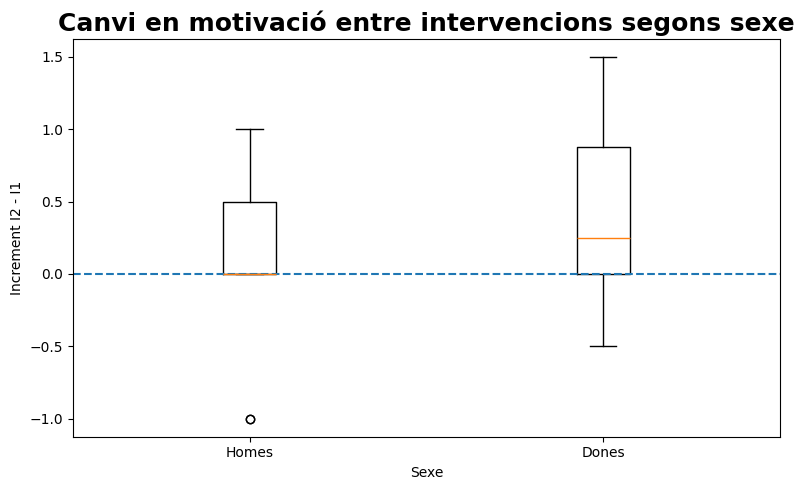

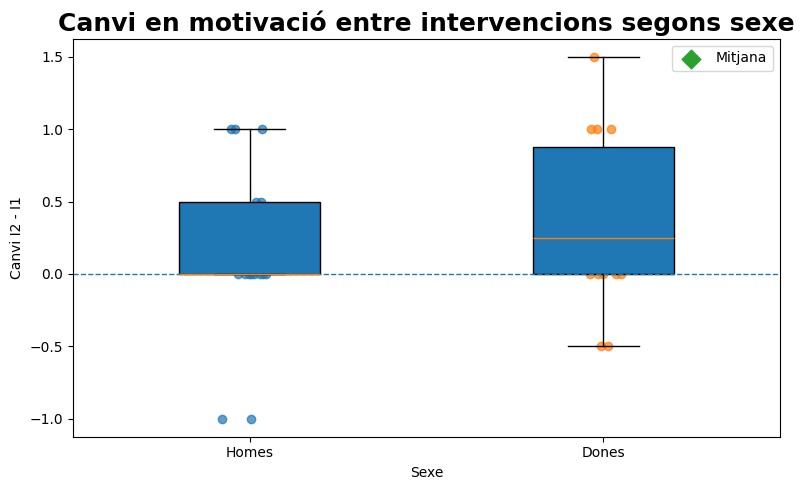

In [47]:
# ============================================================
# GRÀFIC APARELLAT
# Canvi I2 - I1 segons sexe
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# Variable a estudiar
variable = "motivacio_implicacio"

# Preparem parelles
parelles = preparar_parelles(df, variable)

# Calculem canvi
parelles["Canvi"] = (
    parelles["I2"] - parelles["I1"]
)

# Afegim sexe
sexe = (
    df[
        ["Identificador", "Sexe"]
    ]
    .drop_duplicates("Identificador")
    .set_index("Identificador")
)

parelles = parelles.join(
    sexe,
    how="left"
)

# Separació per grups
homes = parelles[
    parelles["Sexe"] == "H"
]["Canvi"]

dones = parelles[
    parelles["Sexe"] == "D"
]["Canvi"]

# ============================================================
# PLOT
# ============================================================

fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.boxplot(
    [homes, dones],
    labels=["Homes", "Dones"]
)

ax.axhline(
    y=0,
    linestyle="--"
)

ax.set_title(
    "Canvi en motivació entre intervencions segons sexe",
    fontsize=18,
    fontweight="bold"
)

ax.set_ylabel(
    "Increment I2 - I1"
)

ax.set_xlabel(
    "Sexe"
)

plt.tight_layout()
plt.show()# ============================================================
# GRÀFIC PROFESSIONAL
# Canvi I2-I1 segons sexe
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# Variable
variable = "motivacio_implicacio"

# ---------- Preparem dades ----------
parelles = preparar_parelles(df, variable)

parelles["Canvi"] = (
    parelles["I2"] - parelles["I1"]
)

# Afegim sexe
info = (
    df[
        ["Identificador", "Sexe"]
    ]
    .drop_duplicates("Identificador")
    .set_index("Identificador")
)

parelles = parelles.join(
    info,
    how="left"
)

# ---------- Figura ----------
fig, ax = plt.subplots(
    figsize=(8,5)
)

# Dades
homes = parelles[
    parelles["Sexe"] == "H"
]["Canvi"].dropna()

dones = parelles[
    parelles["Sexe"] == "D"
]["Canvi"].dropna()

# Boxplot discret
bp = ax.boxplot(
    [homes, dones],
    positions=[1, 2],
    widths=0.4,
    patch_artist=True,
    showfliers=False
)

# Punts individuals
rng = np.random.default_rng(42)

x_h = 1 + rng.normal(0, 0.04, len(homes))
x_d = 2 + rng.normal(0, 0.04, len(dones))

ax.scatter(
    x_h,
    homes,
    alpha=0.7
)

ax.scatter(
    x_d,
    dones,
    alpha=0.7
)

# Mitjana
ax.scatter(
    [1,2],
    [homes.mean(), dones.mean()],
    marker="D",
    s=90,
    label="Mitjana"
)

# línia zero
ax.axhline(
    0,
    linestyle="--",
    linewidth=1
)

# Etiquetes
ax.set_xticks([1,2])
ax.set_xticklabels(
    ["Homes", "Dones"]
)

ax.set_ylabel(
    "Canvi I2 - I1"
)

ax.set_xlabel(
    "Sexe"
)

ax.set_title(
    "Canvi en motivació entre intervencions segons sexe",
    fontsize=18,
    fontweight="bold"
)

ax.legend()

plt.tight_layout()
plt.show()

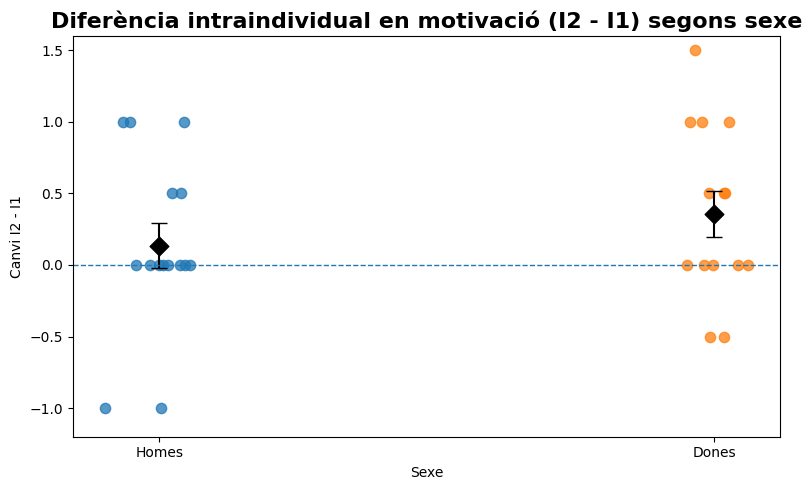

In [51]:
fig, ax = plt.subplots(figsize=(8,5))

rng = np.random.default_rng(42)
ax.set_ylim(-1.2, 1.6)
grups = {
    "Homes": homes,
    "Dones": dones
}

for i, (nom, valors) in enumerate(grups.items(), start=1):
    x = i + rng.normal(0, 0.05, len(valors))
    
    ax.scatter(
        x,
        valors,
        alpha=0.75,
        s=55
    )
    
    ax.scatter(
        i,
        valors.mean(),
        marker="D",
        s=90,
        color="black",
        zorder=3,
        label="Mitjana" if i == 1 else ""
    )
    
    ax.errorbar(
        i,
        valors.mean(),
        yerr=valors.std(ddof=1) / np.sqrt(len(valors)),
        fmt="none",
        color="black",
        capsize=6,
        linewidth=1.5
    )

    

ax.axhline(0, linestyle="--", linewidth=1)

ax.set_xticks([1, 2])
ax.set_xticklabels(["Homes", "Dones"])

ax.set_ylabel("Canvi I2 - I1")
ax.set_xlabel("Sexe")

ax.set_title(
    "Diferència intraindividual en motivació (I2 - I1) segons sexe",
    fontsize=16,
    fontweight="bold"
)


plt.tight_layout()
plt.show()

In [52]:
# ============================================================
# COMPARACIÓ DEL CANVI I2-I1 SEGONS GRUPS MÚLTIPLES
# ============================================================

from scipy.stats import f_oneway, kruskal

def comparar_canvi_per_grup_multiple(df, variable, grup_col):
    """
    Compara el canvi I2 - I1 segons una variable categòrica
    amb més de dos grups, per exemple nivell_matematic.

    Retorna:
    - estadística descriptiva per grup
    - ANOVA d'un factor sobre els canvis
    - Kruskal-Wallis sobre els canvis
    - dades utilitzades
    """

    # ---------- Parelles I1-I2 ----------
    parelles = preparar_parelles(df, variable)
    parelles["Diferencia_I2_I1"] = parelles["I2"] - parelles["I1"]

    # ---------- Afegim variable de grup ----------
    info_grup = (
        df[["Identificador", grup_col]]
        .drop_duplicates("Identificador")
        .set_index("Identificador")
    )

    dades = parelles.join(info_grup, how="left").dropna()

    # ---------- Descriptiva ----------
    descriptiva = (
        dades
        .groupby(grup_col)["Diferencia_I2_I1"]
        .agg(
            n="count",
            mitjana="mean",
            sd="std",
            mediana="median"
        )
        .reset_index()
    )

    # ---------- Llistes per grup ----------
    grups = [
        grup["Diferencia_I2_I1"].dropna()
        for _, grup in dades.groupby(grup_col)
    ]

    # ---------- ANOVA ----------
    if len(grups) >= 2:
        f_stat, p_anova = f_oneway(*grups)
    else:
        f_stat, p_anova = np.nan, np.nan

    # ---------- Kruskal-Wallis ----------
    if len(grups) >= 2:
        h_stat, p_kruskal = kruskal(*grups)
    else:
        h_stat, p_kruskal = np.nan, np.nan

    resultat = pd.DataFrame({
        "variable": [variable],
        "grup": [grup_col],
        "F_anova": [f_stat],
        "p_anova": [p_anova],
        "H_kruskal": [h_stat],
        "p_kruskal": [p_kruskal]
    })

    return resultat, descriptiva, dades

In [53]:
resultat_H5, desc_H5, dades_H5 = comparar_canvi_per_grup_multiple(
    df,
    "Nota_Exercicis",
    "nivell_matematic"
)

resultat_H5

,variable,grup,F_anova,p_anova,H_kruskal,p_kruskal
0,Nota_Exercicis,nivell_matematic,6.589656,0.004243,6.848627,0.032572


In [54]:
desc_H5

,nivell_matematic,n,mitjana,sd,mediana
0,baix,8,2.500000,3.779645,1.25
1,mitja,15,-1.166667,2.288689,0.00
2,alt,10,-1.250000,1.317616,-1.25


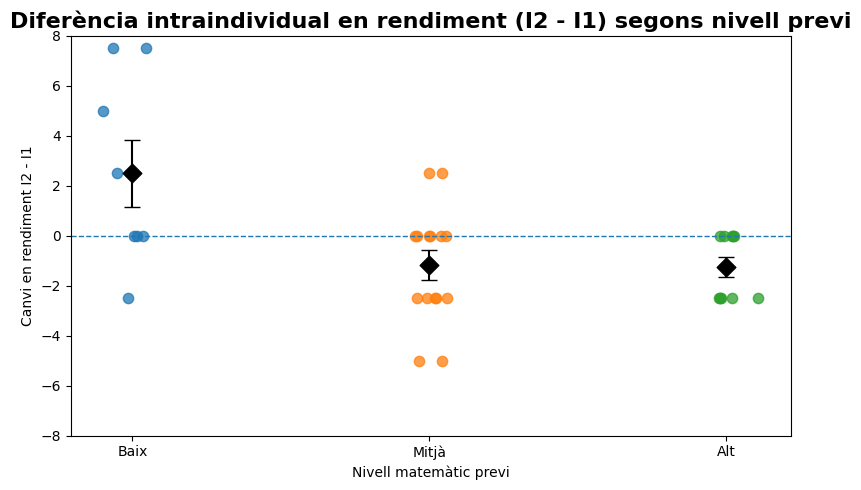

In [58]:
# ============================================================
# GRÀFIC H5
# Canvi en rendiment I2-I1 segons nivell matemàtic previ
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

variable = "Nota_Exercicis"

parelles = preparar_parelles(df, variable)
parelles["Canvi"] = parelles["I2"] - parelles["I1"]

info = (
    df[["Identificador", "nivell_matematic"]]
    .drop_duplicates("Identificador")
    .set_index("Identificador")
)

parelles = parelles.join(info, how="left").dropna()

ordre = ["baix", "mitja", "alt"]
etiquetes = ["Baix", "Mitjà", "Alt"]

fig, ax = plt.subplots(figsize=(8, 5))

rng = np.random.default_rng(42)

for i, nivell in enumerate(ordre, start=1):
    valors = parelles.loc[
        parelles["nivell_matematic"] == nivell,
        "Canvi"
    ].dropna()

    x = i + rng.normal(0, 0.05, len(valors))

    ax.scatter(
        x,
        valors,
        alpha=0.75,
        s=55
    )

    mitjana = valors.mean()
    sem = valors.std(ddof=1) / np.sqrt(len(valors))

    ax.scatter(
        i,
        mitjana,
        marker="D",
        s=90,
        color="black",
        zorder=3
    )

    ax.errorbar(
        i,
        mitjana,
        yerr=sem,
        fmt="none",
        color="black",
        capsize=6,
        linewidth=1.5
    )

ax.axhline(0, linestyle="--", linewidth=1)

ax.set_xticks([1, 2, 3])
ax.set_xticklabels(etiquetes)
ax.set_ylim(-8, 8)
ax.set_ylabel("Canvi en rendiment I2 - I1")
ax.set_xlabel("Nivell matemàtic previ")

ax.set_title(
    "Diferència intraindividual en rendiment (I2 - I1) segons nivell previ",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.savefig(
    "grafics_TFM/canvi_rendiment_nivell.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [60]:
# ============================================================
# EXPORTACIÓ DEFINITIVA DE RESULTATS A EXCEL
# ============================================================

from pathlib import Path
import openpyxl 

SORTIDA = Path("Codis anàlisi/resultats_TFM")
SORTIDA.mkdir(parents=True, exist_ok=True)

fitxer_sortida = SORTIDA / "resultats_definitius_TFM.xlsx"

# ------------------------------------------------------------
# TAULA H3 DESCRIPTIVA
# ------------------------------------------------------------

h3_descriptiva = pd.DataFrame({
    "Dimensió": [
        "Motivació i implicació", "Motivació i implicació",
        "Claredat del material", "Claredat del material",
        "Baixa càrrega cognitiva", "Baixa càrrega cognitiva"
    ],
    "Intervenció": [
        "I1", "I2",
        "I1", "I2",
        "I1", "I2"
    ],
    "Mitjana": [
        4.12, 4.36,
        4.36, 4.41,
        3.76, 4.08
    ],
    "Desv. std.": [
        0.73, 0.60,
        0.52, 0.50,
        0.65, 0.77
    ],
    "Mediana": [
        4.00, 4.50,
        4.50, 4.50,
        3.50, 4.50
    ]
})

# ------------------------------------------------------------
# TAULA H3 INFERENCIAL
# ------------------------------------------------------------

h3_inferencial = pd.DataFrame({
    "Dimensió": [
        "Motivació i implicació",
        "Claredat del material",
        "Baixa càrrega cognitiva"
    ],
    "t aparellat": [
        2.142,
        0.384,
        2.361
    ],
    "p t-test aparellat": [
        0.041,
        0.704,
        0.025
    ],
    "p Wilcoxon": [
        0.050,
        0.974,
        0.034
    ],
    "Cohen dz": [
        0.40,
        0.07,
        0.44
    ]
})

# ------------------------------------------------------------
# EXPORTACIÓ
# ------------------------------------------------------------

with pd.ExcelWriter(fitxer_sortida, engine="xlsxwriter") as writer:

    # Full resum
    pd.DataFrame({
        "Contingut": [
            "Resultats definitius del TFM",
            "Anàlisi corregida amb dades aparellades",
            "Les comparacions I1-I2 es fan sobre alumnes amb dades vàlides a les dues intervencions",
            "Diferència definida com I2 - I1"
        ]
    }).to_excel(writer, sheet_name="README", index=False)

    # Hipòtesis
    resultat_H1.to_excel(writer, sheet_name="H1_rendiment", index=False)
    resultat_H2.to_excel(writer, sheet_name="H2_rigor", index=False)

    h3_descriptiva.to_excel(writer, sheet_name="H3_descriptiva", index=False)
    h3_inferencial.to_excel(writer, sheet_name="H3_inferencial", index=False)

    resultat_H4.to_excel(writer, sheet_name="H4_genere", index=False)
    dades_H4.to_excel(writer, sheet_name="H4_dades_canvi", index=True)

    resultat_H5.to_excel(writer, sheet_name="H5_nivell", index=False)
    desc_H5.to_excel(writer, sheet_name="H5_descriptiva", index=False)
    dades_H5.to_excel(writer, sheet_name="H5_dades_canvi", index=True)

    # Dades base processades
    df.to_excel(writer, sheet_name="Dades_processades", index=False)

    # Parelles utilitzades
    parelles_H1.to_excel(writer, sheet_name="Parelles_H1", index=True)
    parelles_H2.to_excel(writer, sheet_name="Parelles_H2", index=True)

    # Format bàsic
    workbook = writer.book

    header_format = workbook.add_format({
        "bold": True,
        "bg_color": "#D9EAF7",
        "border": 1
    })

    number_format = workbook.add_format({
        "num_format": "0.000"
    })

    for sheet_name, worksheet in writer.sheets.items():
        worksheet.freeze_panes(1, 0)
        worksheet.set_column(0, 0, 22)
        worksheet.set_column(1, 20, 16, number_format)

        for col_num, value in enumerate(
            pd.read_excel(fitxer_sortida, sheet_name=sheet_name).columns
            if False else []
        ):
            worksheet.write(0, col_num, value, header_format)

print(f"Excel definitiu creat correctament a: {fitxer_sortida}")

Excel definitiu creat correctament a: Codis anàlisi/resultats_TFM/resultats_definitius_TFM.xlsx
